<a href="https://colab.research.google.com/github/yannelye/undergrad_ml_assignments/blob/main/04_assignment_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Assignment 4: Regularization**
Yannely Escalante Ruiz

usw5zk

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1. Adding a penalty to mean squared error discourages the model from using very large coefficients. The intuition is that large parameter values can make the model overly sensitive to small changes in the data, so the penalty encourages simpler and more stable models by keeping coefficients small.

2. Regularization helps explore the bias-variance trade-off by controlling model complexity. As the penalty increases, the model becomes simpler, which usually increases bias but reduces variance. This allows us to find a balance where the model is not overfitting but still captures the main patterns in the data.

3. The main difference between LASSO and Ridge regression is the type of penalty used. LASSO uses an absolute value penalty, which can shrink some coefficients exactly to zero and perform feature selection. Ridge uses a squared penalty, which shrinks coefficients toward zero but does not eliminate them completely. As a result, LASSO produces sparser models, while Ridge keeps all features but with reduced magnitudes.

4. We typically scale variables before applying regularized regression so that all features are on the same scale. This is important because the penalty depends on coefficient size, and without scaling, variables with larger units would be unfairly penalized more than others.

5. The penalty parameter α is usually chosen using cross validation. We test different values of α and select the one that gives the best performance on validation data, often minimizing prediction error.

6. When doing cross validation, the penalty term is not included in the evaluation of the cross validated MSE. This is because we want to measure how well the model predicts new data, and MSE should reflect only prediction error, not the size of the coefficients.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [1]:
! git clone https://github.com/ds4e/undergrad_ml_assignments

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 126 (delta 0), reused 0 (delta 0), pack-reused 124 (from 2)
Receiving objects: 100% (126/126), 12.31 MiB | 12.14 MiB/s, done.
Resolving deltas: 100% (45/45), done.


In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv('./undergrad_ml_assignments/data/cars_hw.csv')

df = df.drop(columns=['Unnamed: 0'])

df['Age'] = 2024 - df['Make_Year']

X = df[['Mileage_Run', 'Age']]
y = df['Price']

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [3]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_scaled, y)

feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

for name, coef in zip(feature_names, model.coef_):
    print(name, coef)

Mileage_Run 668616.517209674
Age -184194.14613723248
Mileage_Run^2 -149467.87417613144
Mileage_Run Age -1251592.3408260453
Age^2 215639.8787572434
Mileage_Run^3 -65144.89659917474
Mileage_Run^2 Age 283339.15222242544
Mileage_Run Age^2 528082.863474972
Age^3 -138937.02579369987


**Q2.2 Answer:** The Mileage_Run and Age is negative, meaning that as both mileage and age increase at the same time, the car’s price drops more than what you’d expect from each factor on its own. In other words, cars that are both older and have higher mileage tend to depreciate at a faster rate.

In [4]:
from sklearn.linear_model import LassoCV
import numpy as np

alphas = np.logspace(1, 3, 20)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)

lasso.fit(X_scaled, y)

print("Best alpha:", lasso.alpha_)

Best alpha: 483.2930238571752


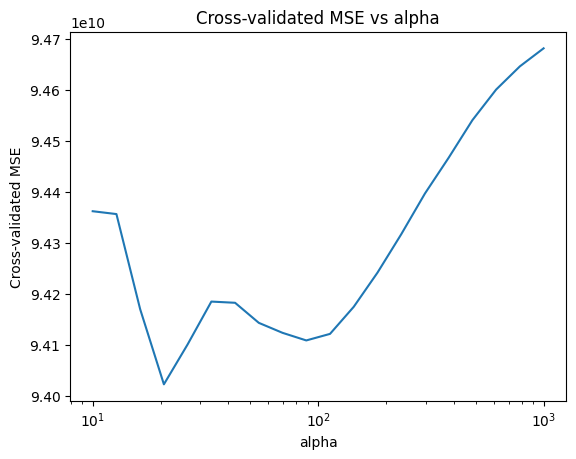

In [5]:
import matplotlib.pyplot as plt

mse_mean = lasso.mse_path_.mean(axis=1)

plt.plot(alphas, mse_mean)
plt.xscale('log')

plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.title('Cross-validated MSE vs alpha')

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.408e+11, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.686e+11, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.202e+11, tolerance: 1.316e

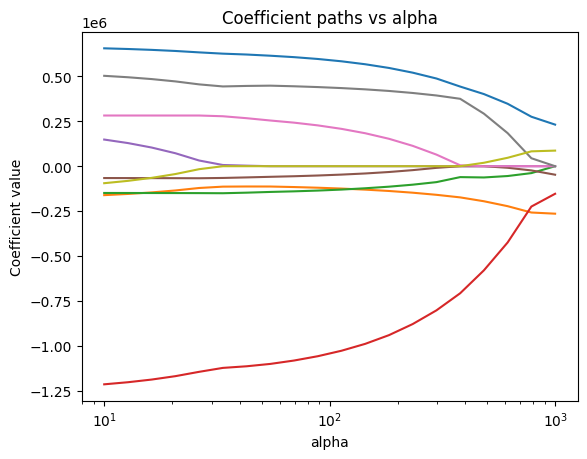

In [6]:
from sklearn.linear_model import Lasso
import numpy as np
import matplotlib.pyplot as plt

coefs = []

for a in alphas:
    lasso_temp = Lasso(alpha=a, max_iter=10000)
    lasso_temp.fit(X_scaled, y)
    coefs.append(lasso_temp.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('Coefficient paths vs alpha')

plt.show()

In [7]:
coefs = lasso.coef_

feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

selected = feature_names[coefs != 0]

prop_zero = np.mean(coefs == 0)

print("Selected features:", selected)
print("Proportion set to zero:", prop_zero)

Selected features: ['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Mileage_Run Age^2'
 'Age^3']
Proportion set to zero: 0.3333333333333333


**Q2.6 Answer:** The features include Mileage_Run, Age, Mileage_Run², Mileage_Run × Age, Mileage_Run × Age², and Age³. Around 33% of the coefficients are zero, which shows that LASSO eliminates less significant variables to create a simpler, more streamlined model.

In [8]:
for name, lin, las in zip(feature_names, model.coef_, lasso.coef_):
    print(f"{name}: Linear={lin:.2f}, Lasso={las:.2f}")

Mileage_Run: Linear=668616.52, Lasso=401025.26
Age: Linear=-184194.15, Lasso=-194803.12
Mileage_Run^2: Linear=-149467.87, Lasso=-62539.29
Mileage_Run Age: Linear=-1251592.34, Lasso=-578788.66
Age^2: Linear=215639.88, Lasso=-0.00
Mileage_Run^3: Linear=-65144.90, Lasso=-0.00
Mileage_Run^2 Age: Linear=283339.15, Lasso=0.00
Mileage_Run Age^2: Linear=528082.86, Lasso=292015.03
Age^3: Linear=-138937.03, Lasso=19133.91


**Q2.7 Answer:** Compared to standard linear regression, LASSO produces smaller coefficient values overall because it applies a penalty that shrinks them. Some coefficients become exactly zero—for example, Mileage_Run³ and Mileage_Run² × Age—meaning those variables are excluded from the model entirely. None of the coefficients become larger in magnitude when moving from linear regression to LASSO. Most retain the same sign, though a few may shift slightly due to correlations among predictors. Overall, LASSO results in a more simplified model by reducing coefficient sizes and removing less relevant features.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [9]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv('./undergrad_ml_assignments/data/heart_failure_clinical_records_dataset.csv')

X_cont = df[['age', 'ejection_fraction', 'serum_creatinine']]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_cont)

scaler_cont = StandardScaler()
X_poly_scaled = scaler_cont.fit_transform(X_poly)

X_cat = df[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]

poly_cat = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_cat_inter = poly_cat.fit_transform(X_cat)

scaler_cat = StandardScaler()
X_cat_inter_scaled = scaler_cat.fit_transform(X_cat_inter)

X_final = np.hstack([X_poly_scaled, X_cat_inter_scaled])

y = df['DEATH_EVENT']

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_final, y)

coefs = model.coef_

print(coefs)

[ 1.53915561 -2.19249366 -0.85358815 -3.67865393 -0.60091803  1.84156257
  3.43097646  2.67339362 -2.64704061  1.99313494  0.90802595 -0.69752151
 -0.08120632 -1.57766526  1.28409929 -1.25034105 -1.27004314  1.17947493
  0.07215578  0.00400805 -0.03487459 -0.00378736 -0.04794311  0.00998995
 -0.01000373  0.02060583  0.04647419  0.04689299  0.0304818 ]


**Q3.2 Answer:** Yes, some coefficient signs may seem counterintuitive, for example a variable expected to increase the risk of death might have a negative coefficient. This happens because the model includes interaction and higher-order terms, which make relationships between variables more complex and dependent on each other. As a result, individual coefficients cannot be interpreted on their own. These added terms allow the model to capture more realistic patterns in the data, so even if some coefficients look unusual, the overall model is still more accurate.

In [11]:
from sklearn.linear_model import LassoCV
import numpy as np

alphas = np.logspace(-5, 5, 30)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)

lasso.fit(X_final, y)

print("Best alpha:", lasso.alpha_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.1571131221602329, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.0211058802483066, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7.9557016170357215, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Co

Best alpha: 0.005736152510448681


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 6.822671897121349, tolerance: 0.006354929577464795
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 10.297004566088537, tolerance: 0.006354929577464795
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.4330492498154541, tolerance: 0.006366315789473686
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Con

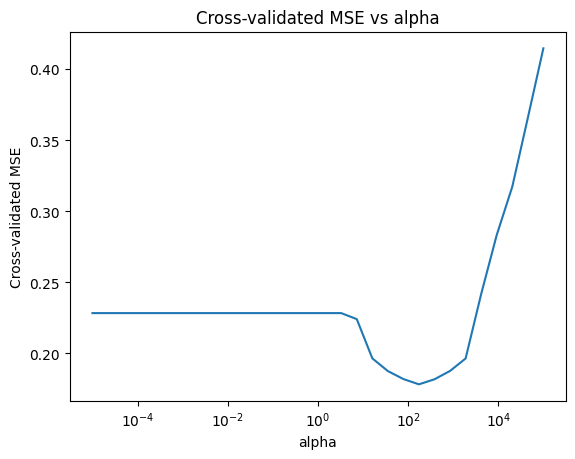

In [12]:
import matplotlib.pyplot as plt

mse_mean = lasso.mse_path_.mean(axis=1)

plt.plot(alphas, mse_mean)
plt.xscale('log')

plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.title('Cross-validated MSE vs alpha')

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.908e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.666e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.162e+01, tolerance: 6.518e

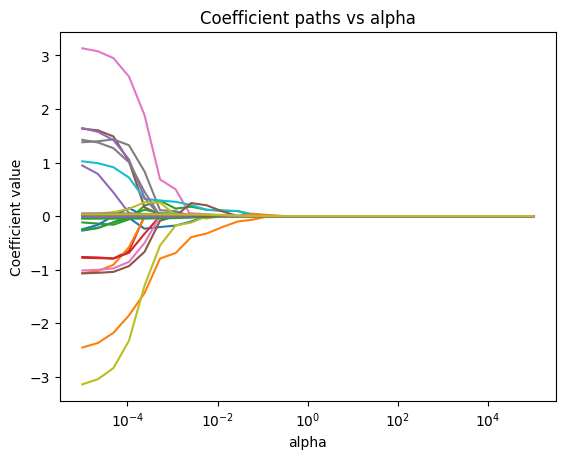

In [13]:
from sklearn.linear_model import Lasso
import numpy as np
import matplotlib.pyplot as plt

coefs = []

for a in alphas:
    lasso_temp = Lasso(alpha=a, max_iter=10000)
    lasso_temp.fit(X_final, y)
    coefs.append(lasso_temp.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('Coefficient paths vs alpha')

plt.show()

In [14]:
lasso_coefs = lasso.coef_
linear_coefs = model.coef_

prop_zero = np.mean(lasso_coefs == 0)

print("Proportion set to zero:", prop_zero)

for lin, las in zip(linear_coefs, lasso_coefs):
    print(f"Linear={lin:.4f}, Lasso={las:.4f}")

Proportion set to zero: 0.5862068965517241
Linear=1.5392, Lasso=-0.0000
Linear=-2.1925, Lasso=-0.3261
Linear=-0.8536, Lasso=0.1174
Linear=-3.6787, Lasso=0.0000
Linear=-0.6009, Lasso=-0.0000
Linear=1.8416, Lasso=0.0000
Linear=3.4310, Lasso=0.0000
Linear=2.6734, Lasso=0.0000
Linear=-2.6470, Lasso=-0.0000
Linear=1.9931, Lasso=0.1162
Linear=0.9080, Lasso=0.0000
Linear=-0.6975, Lasso=0.0000
Linear=-0.0812, Lasso=0.0000
Linear=-1.5777, Lasso=0.0000
Linear=1.2841, Lasso=-0.0000
Linear=-1.2503, Lasso=0.2008
Linear=-1.2700, Lasso=0.0344
Linear=1.1795, Lasso=-0.0000
Linear=0.0722, Lasso=-0.0456
Linear=0.0040, Lasso=0.0132
Linear=-0.0349, Lasso=0.0000
Linear=-0.0038, Lasso=0.0000
Linear=-0.0479, Lasso=-0.0198
Linear=0.0100, Lasso=0.0003
Linear=-0.0100, Lasso=-0.0000
Linear=0.0206, Lasso=0.0000
Linear=0.0465, Lasso=0.0245
Linear=0.0469, Lasso=0.0174
Linear=0.0305, Lasso=0.0258


**Q3.6 Answer:** LASSO keeps only the most important features and sets many others to zero. In this case, about 59% of the features are eliminated, removing many less useful variables.
Compared to linear regression, LASSO produces smaller coefficients and sets many of them exactly to zero, while none become larger. Most coefficients keep the same sign, with only slight changes in a few cases.
Overall, the LASSO model is more interpretable because it reduces noise and focuses on key predictors. In terms of bias and variance, it slightly increases bias by simplifying the model but significantly reduces variance, which can improve performance on new data.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

Link for the google doc where I answer Q4!:

https://docs.google.com/document/d/12X5u4_jeJB7tM1jsmmp1tg0zk0mvz8fA9iy_vBOxR3s/edit?tab=t.0